---

## 상태 이력 관리

체크포인트 기반으로 상태를 저장/복원하여 롤백/재실행합니다. 이 기능을 통해 특정 시점으로 돌아가 다른 경로로 실행하거나, 실행 이력을 분석할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| State History | 그래프 실행 중 발생한 모든 상태 변경 이력 |
| Checkpoint ID | 특정 시점의 상태를 식별하는 고유 ID |
| Rollback | 지정한 체크포인트로 상태를 복원 |
| Resume | 복원된 상태에서 실행을 재개 |

아래 섹션에서는 체크포인트 기반 상태 관리를 실습합니다.

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


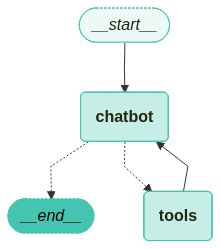

In [1]:
from feature.persistence.Replay import Replay

workflow = Replay()
workflow.show_graph()

### 체크포인트 시퀀스 생성

여러 번 대화를 실행하여 상태 이력을 생성합니다. 각 실행마다 새로운 체크포인트가 생성되어 나중에 특정 시점으로 롤백할 수 있습니다.

아래 코드는 첫 번째 검색 대화를 실행합니다.

In [2]:
from langchain_core.messages import HumanMessage
from langgraph.graph.state import RunnableConfig


time_travel_config = RunnableConfig(configurable={"thread_id": "time-travel-30"})


# 첫 번째 대화
workflow.stream(
    inputs={"messages": [HumanMessage(content="테디노트에 대해서 조사 좀 해주세요.")]},
    config=time_travel_config,
    node_names=['chatbot']
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
테디노트(TeddyNote)는 주로 데이터 분석 및 AI 관련 콘텐츠를 다루는 블로그와 유튜브 채널을 운영하는 개인입니다. 다음은 테디노트에 대한 자세한 정보입니다:

1. **운영자**: 테디노트는 Teddy Lee라는 이름으로 알려진 사람이며, 다양한 IT 및 AI 관련 프로젝트에서 활동하고 있습니다.
2. **채널 및 블로그**: 테디노트 블로그와 유튜브 채널에서는 파이썬, 딥러닝, 랭체인(LangChain)과 같은 주제를 학습할 수 있는 자료를 제공합니다.
3. **저서**: 그는 "파이썬 딥러닝 텐서플로"와 다양한 데이터 분석 관련 전자책을 집필하였습니다. 예를 들어, 최근에는 "랭체인 한국어 튜토리얼"과 "테디노트의 RAG 비법노트" 시리즈를 출판했습니다.
4. **경력**: 
   - 삼성전자에서 소프트웨어 개발자로 근무하였으며, 이후 여러 기술 기업에서 CTO 및 CEO로 활동하고 있습니다.
   - LangChain의 앰배서더로도 활동하고 있으며, 관련 콘텐츠를 한국어로 제공하고 있습니다.

### 참고 링크
- [Teddy Lee - LinkedIn 프로필](https://kr.linkedin.com/in/teddy-lee)
- [테디노트 - 위키독스 프로필](https://wikidocs.net/profile/info/book/10226)

테디노트는 데이터 과학 및 인공지능 분야에서 지식 공유에 실제로 많은 기여를 하고 있으며, 관련 자료를 통해 많은 사람들에게 도움을 주고 있습니다.

In [3]:
# 두번쨰 대화
workflow.stream(
    inputs={"messages": [HumanMessage(content="pgvector란?")]},
    config=time_travel_config,
    node_names=['chatbot']
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
**pgvector**는 PostgreSQL 데이터베이스에 벡터 유사성 검색 기능을 제공하는 오픈 소스 확장 프로그램입니다. 최근에는 0.7.0 버전이 출시되었으며, 이 버전에서는 여러 새로운 벡터 유형과 기능이 추가되었습니다. 주된 내용은 다음과 같습니다:

1. **벡터 저장 및 검색**:
   - pgvector는 텍스트, 이미지, 오디오 등 다양한 데이터 유형의 임베딩을 저장하고 검색할 수 있습니다. 이 임베딩은 데이터를 수학적으로 표현한 고차원 벡터입니다.
   - 최대 2,000 차원까지 벡터를 인덱싱할 수 있으며, 더 높은 차원의 벡터의 경우 주성분 분석(PCA)과 같은 차원 축소 방법을 사용할 수 있습니다.

2. **효율적인 최근접 이웃 검색**:
   - 최근접 이웃 검색을 위한 효율적인 알고리즘을 제공하며, 이는 정확한 검색과 근사 검색을 모두 포함합니다.

3. **쿼리 연산자**:
   - pgvector는 벡터 데이터에 대해 다양한 연산자를 제공합니다. 예를 들어 `<->` 연산자는 두 벡터 간의 유클리드 거리(L2 거리)를 계산합니다. 이 거리가 작을수록 두 벡터 간의 유사성이 높다는 것을 의미합니다.

4. **향상된 기능**:
   - 최근 버전에서는 새로운 벡터 유형인 `halfvec` 및 `sparsevec`가 추가되었고, 이진 벡터를 위한 인덱싱도 지원합니다. 또한 HNSW 인덱싱과 같은 새로운 거리 함수도 도입되었습니다.

pgvector는 머신러닝 및 데이터 과학 분야에서 고차원 데이터의 유사성 검색에 매우 유용하게 사용되며, AI 혁명과 함께 그 중요성이 더욱 커지고 있습니다. 

### 추가 링크
- [PostgreSQL pgvector 0.7.0 출시 소식](https://www.postgresql.org/about/news/pgvector-070-released-2852/)
- [pgvect

### 상태 이력 탐색

`get_state_history`로 전체 상태 이력을 조회하고 롤백할 체크포인트를 선택합니다. 이력은 최신순으로 반환되며, 각 체크포인트에는 해당 시점의 상태 정보가 포함됩니다.

아래 코드는 상태 이력을 조회하고 특정 조건(메시지 수가 6개)에 해당하는 체크포인트를 선택합니다.

In [4]:
# 전체 상태 히스토리 확인
from util.messages import display_message_tree


print("상태 히스토리 (최신순):")
print("=" * 80)

# to_replay 변수 초기화
to_replay = None

for i, state in enumerate(workflow.graph.get_state_history(time_travel_config)):
    print(f"\n[체크포인트 {i}]")
    print(f"  다음 노드: {state.next}")
    print(f"  체크포인트 ID: {state.config['configurable']['checkpoint_id']}")

    if len(state.values["messages"]) == 6 and to_replay is None:
        print("  이 상태로 되돌아갈 예정")
        display_message_tree(state.values["messages"][-1])
        to_replay = state


print("\n" + "=" * 80)

상태 히스토리 (최신순):

[체크포인트 0]
  다음 노드: ()
  체크포인트 ID: 1f14ed0d-44bc-6ef4-8008-46c571ef6897

[체크포인트 1]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f14ed0c-f899-632e-8007-74a9b2cec9ff

[체크포인트 2]
  다음 노드: ('tools',)
  체크포인트 ID: 1f14ed0c-f2b8-60cc-8006-6a7fdd702247
  이 상태로 되돌아갈 예정
    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-4o-mini-2024-07-18", "system_fingerprint": "fp_026a2c69f4", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--019e218e-0069-7ad1-8fd2-c4f27149c2d7"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "pgvector", "search_depth": "advanced"}
            id: "call_KLh2EaNyKiaTuecLyThc65It"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3698
        output_tokens: 22
        total_tokens: 3720
        input_token_details: {"audio": 0, "cache_read": 3584}
        output_toke

### 체크포인트로 롤백

선택한 체크포인트의 상태를 확인합니다. 이 시점의 마지막 메시지 내용을 표시하여 어느 지점으로 돌아갈지 확인할 수 있습니다.

아래 코드는 선택한 체크포인트의 마지막 메시지를 표시합니다.

In [5]:
from util.messages import update_tool_call

# 사용 예시:
updated_message = update_tool_call(
    to_replay.values["messages"][-1],
    tool_name="tavily_search",
    tool_args={"query": "redis가 뭐야?", "search_depth": "basic"},
)

In [6]:
# 변경하기 전의 message
display_message_tree(to_replay.values["messages"][-1])

    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-4o-mini-2024-07-18", "system_fingerprint": "fp_026a2c69f4", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--019e218e-0069-7ad1-8fd2-c4f27149c2d7"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "pgvector", "search_depth": "advanced"}
            id: "call_KLh2EaNyKiaTuecLyThc65It"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3698
        output_tokens: 22
        total_tokens: 3720
        input_token_details: {"audio": 0, "cache_read": 3584}
        output_token_details: {"audio": 0, "reasoning": 0}


In [7]:
# 변경한 이후의 메시지 트리
display_message_tree(updated_message)

    content: ""
    additional_kwargs: {}
    response_metadata: {"finish_reason": "tool_calls", "model_name": "gpt-4o-mini-2024-07-18", "system_fingerprint": "fp_026a2c69f4", "service_tier": "default", "model_provider": "openai"}
    type: "ai"
    name: None
    id: "lc_run--019e218e-0069-7ad1-8fd2-c4f27149c2d7"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "redis가 뭐야?", "search_depth": "basic"}
            id: "call_KLh2EaNyKiaTuecLyThc65It"
            type: "tool_call"
    invalid_tool_calls:
    usage_metadata:
        input_tokens: 3698
        output_tokens: 22
        total_tokens: 3720
        input_token_details: {"audio": 0, "cache_read": 3584}
        output_token_details: {"audio": 0, "reasoning": 0}


In [19]:
to_replay.next

('tools',)

In [20]:
# 변경된 메시지를 update_state 로 업데이트
updated_state = workflow.graph.update_state(
    values={"messages": [updated_message]}, config=to_replay.config
)

### 수정 상태 재실행

업데이트된 상태로 그래프를 재실행하여 결과를 확인합니다. `update_state` 메서드로 상태를 수정하면 해당 시점부터 새로운 경로로 실행이 계속됩니다.

아래 코드는 수정된 검색 쿼리로 그래프를 재실행합니다.

- LangSmith 추적 결과 redis를 검색하긴 하는데 LLM이 이전 대화를 추적하여 다시 pgvector를 검색함

In [21]:
# 업데이트된 메시지를 스트리밍 합니다.
workflow.stream(
    inputs=None,
    config=updated_state,
    node_names=['chatbot']
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
**pgvector**는 PostgreSQL 데이터베이스의 확장 기능으로, 벡터 유사성 검색을 지원하는 기능을 제공합니다. 이 기능은 특히 기계 학습과 관련된 데이터, 즉 높은 차원의 벡터(임베딩)를 저장하고 검색하는 데 유용합니다. 

### 주요 기능
1. **벡터 저장 및 검색**: pgvector는 텍스트, 이미지, 오디오 등 다양한 형식의 임베딩을 저장할 수 있습니다. 최대 2,000 차원의 벡터를 인덱싱할 수 있으며, 더 높은 차원의 벡터는 차원 축소 방법(예: 주성분 분석)으로 처리할 수 있습니다.

2. **유사성 검색**: 벡터 간의 유사성을 계산하여 가장 가까운 이웃을 효율적으로 찾는 알고리즘을 제공합니다. 이는 정확한 결과와 근사값 모두를 지원합니다.

3. **쿼리 연산자**: pgvector는 벡터 데이터를 처리하기 위한 다양한 쿼리 연산자를 제공합니다. 예를 들어, `<->` 연산자는 두 벡터 간의 유클리드 거리(L2 거리)를 계산합니다. 이 거리가 작을수록 두 벡터는 서로 더 유사한 것으로 간주됩니다.

4. **거리 측정 방법**: pgvector는 다양한 거리 측정 방법을 지원합니다. 최근 업데이트에서는 해밍 거리 및 자카드 거리와 같은 새로운 거리 함수가 추가되었습니다.

pgvector는 데이터베이스 내에서 벡터 유사성 검색을 처리하고자 하는 애플리케이션에서 매우 유용하게 사용될 수 있습니다. 

자세한 내용은 [pgvector 공식 웹사이트](https://www.postgresql.org/about/news/pgvector-070-released-2852/)에서 확인하실 수 있습니다.